<a href="https://colab.research.google.com/github/stevehelloworld/AI_DEMO_testing/blob/main/%E6%8A%95%E8%B3%87%E7%AD%96%E7%95%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 低波動、低流動和小規模
**低波動相對穩定
低流動可能有流動性溢酬
小規模成長潛力較大**


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import seaborn as sns

# Setup plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams.update({'font.size': 12})

print("Libraries imported successfully.")

Libraries imported successfully.


In [49]:
# === Load preprocessed TEJ monthly file ===
try:
    df = pd.read_csv("twstock_monthly_2005_2024.csv", parse_dates=['date'])
    print(f"Loaded {df['stock_code'].nunique()} unique stocks and {len(df)} monthly records.")
    # Display the first few rows to confirm
    print(df.head())
except FileNotFoundError:
    print("Error: The file 'twstock_monthly_1990_202506.csv' was not found.")
    print("Please make sure the file is in the same directory as this notebook.")

Loaded 1211 unique stocks and 211732 monthly records.
        date  stock_code stock_name       RET       TOR       ME    PER   PBR  \
0 2005-01-31        1101         台泥 -0.038277  0.091584  0.00389  19.78  1.04   
1 2005-02-25        1101         台泥  0.004975  0.050366  0.00376  19.88  1.05   
2 2005-03-31        1101         台泥 -0.094060  0.106246  0.00351  18.01  0.95   
3 2005-04-29        1101         台泥  0.038253  0.059723  0.00376  18.70  0.98   
4 2005-05-31        1101         台泥 -0.060526  0.057039  0.00341  17.57  0.92   

    PRR    DY       HLD  
0  1.98  1.68  0.129187  
1  1.99  1.67  0.059701  
2  1.80  1.84  0.180693  
3  1.87  1.77  0.095628  
4  1.76  1.89  0.071053  


In [50]:
df['Size_Raw'] = df['ME']
df['Vol_Raw'] = df['HLD']
df['Liq_Raw']  = df['TOR']

In [51]:
print("正在去除極端值 (Winsorizing)...")
my_factors = ['Size_Raw', 'Vol_Raw', 'Liq_Raw']

for col in my_factors:
  df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))
df[my_factors].describe().T

正在去除極端值 (Winsorizing)...


,count,mean,std,min,25%,50%,75%,max
Size_Raw,201801.0,0.000999,0.002508,0.000020,0.000100,0.000240,0.000650,0.017700
Vol_Raw,211154.0,0.154168,0.103816,0.023499,0.081218,0.128736,0.197701,0.581829
Liq_Raw,211731.0,0.142525,0.217677,0.001571,0.023567,0.060523,0.160575,1.298163


In [52]:
def get_z_score(series):
  return (series - series.mean()) / series.std()

df['Strategy_Score']= (
    (df.groupby('date')['Size_Raw'].transform(get_z_score)*-1) +
    (df.groupby('date')['Vol_Raw'].transform(get_z_score)*-1) +
    (df.groupby('date')['Liq_Raw'].transform(get_z_score)*-1)
)


In [53]:
def backtest_portfolio(df, signal='Strategy_Score', top_pct=0.2, cost_bps=40, ascending=True,value_weight=False):
    """
    Sort stocks each month by the chosen signal and invest in the top group.
    Supports equal-weighted or value-weighted portfolio.
    """
    df_copy = df.copy()
    df_copy = df_copy.sort_values(['date','stock_code'])

    # --- Step 1: Rank by signal ---
    # We rank stocks every month based on the chosen signal
    df_copy['rank'] = df_copy.groupby('date')[signal].rank(pct=True, ascending = ascending )

    # --- Step 2: Select Portfolio ---
    # Select the top quintile (top 20%)
    df_copy['selected'] = np.where(df_copy['rank']>=(1- top_pct), 1, 0)

    # --- Step 3: Weighting scheme ---
    if value_weight:
        # Use ME (current market cap) for weighting, not ME_lag (which is the signal)
        # We assume ME is known at the time of portfolio construction (t)
        df_copy['w_raw'] = df_copy['selected'] * df_copy['ME']
    else:
        # Equal weighting
        df_copy['w_raw'] = df_copy['selected']

    # Normalize weights to sum to 1
    df_copy['w_norm'] = df_copy.groupby('date')['w_raw'].transform(lambda x: x / x.sum() if x.sum() != 0 else 0)

    # --- Step 4: Calculate Portfolio Gross Return ---
    # We construct the portfolio at time (t) using signals from (t-1)
    # We hold this portfolio for the next month and capture the return (RET) at (t+1)
    # Therefore, we must shift our weights by 1 to align with the *next* month's RET
    df_copy['w_norm_lag'] = df_copy.groupby('stock_code')['w_norm'].shift(1)

    # Calculate gross return
    port_ret = df_copy.groupby('date', group_keys=False).apply(lambda x: np.sum(x['w_norm_lag'] * x['RET']))
    port_ret.name = 'GrossReturn'

    # --- Step 5: Turnover and Net Return ---
    # We need to pivot to get a (Date x Stock) matrix of weights
    df_unique = df_copy.drop_duplicates(subset=['date','stock_code'], keep='last')
    w = df_unique.pivot(index='date', columns='stock_code', values='w_norm').fillna(0)

    # Turnover is the sum of absolute changes in weights from (t-1) to (t), divided by 2 (buy + sell)
    turnover = (w - w.shift(1)).abs().sum(axis =1)/2

    # Transaction cost in basis points (e.g., 20bps = 0.0020)
    cost = turnover * (cost_bps/10000)

    # Net return is gross return minus costs
    # We align port_ret and cost, ensuring they are from the same period
    net_ret = (port_ret - cost).dropna()
    net_ret.name = 'NetReturn'

    df_out = pd.DataFrame({
        'GrossReturn': port_ret,
        'NetReturn': net_ret,
        'Turnover': turnover
    })
    df_out['Cumulative'] = (1 + df_out['NetReturn']).cumprod()
    return df_out

In [54]:
# === 1. Run Factor Strategies (Value-Weighted) ===
print("Running backtests for Value, Momentum, and Size...")

# 1. Size
res_size_vw = backtest_portfolio(df, signal='ME', ascending=True, top_pct=0.2, cost_bps=20, value_weight=False)

# 2. Volatility
res_vol_vw = backtest_portfolio(df, signal='HLD', ascending=True, top_pct=0.2, cost_bps=20, value_weight=False)

# 3. Liquidity
res_liq_vw = backtest_portfolio(df, signal='TOR', ascending=True, top_pct=40, cost_bps=15, value_weight=False)

# 4. My Strategy
res_my_start = backtest_portfolio(df, signal='Strategy_Score', ascending=False, top_pct=0.2, cost_bps=20, value_weight=False)

Running backtests for Value, Momentum, and Size...


/tmp/ipython-input-551339436.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  port_ret = df_copy.groupby('date', group_keys=False).apply(lambda x: np.sum(x['w_norm_lag'] * x['RET']))
/tmp/ipython-input-551339436.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  port_ret = df_copy.groupby('date', group_keys=False).apply(lambda x: np.sum(x['w_norm_lag'] * x['RET']))
/tmp/ipython-input-551339436.py:36: 

In [55]:
# === 2. Download TWII Benchmark ===
print("Downloading TAIEX (^TWII) benchmark data...")
try:
    twii_close = yf.download("^TWII", start="2004-12-31", end="2025-01-01", progress=False)['Close']
    twii_m = twii_close.resample("ME").last() # 'ME' = Month-End frequency
    ret_twii = twii_m.pct_change().dropna()
    ret_twii.name = "TWII"
    print("Benchmark download complete.")
    print(ret_twii.head())
except Exception as e:
    print(f"Error downloading benchmark: {e}\nUsing placeholder data.")
    # Create a placeholder if download fails
    placeholder_index = res_my_start.index
    ret_twii = pd.Series(np.random.normal(0.005, 0.05, len(placeholder_index)),
                         index=placeholder_index, name="TWII")

Benchmark download complete.
Ticker         ^TWII
Date                
2005-01-31 -0.023692
2005-02-28  0.035634
2005-03-31 -0.032532
2005-04-30 -0.031271
2005-05-31  0.033257


/tmp/ipython-input-4059328451.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  twii_close = yf.download("^TWII", start="2004-12-31", end="2025-01-01", progress=False)['Close']


In [56]:
# === 3. Performance Summary Function ===
def performance_report(r):
    """
    Calculates key performance metrics for a return series.
    """
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return pd.Series({
            'Annual Return': np.nan, 'Annual Volatility': np.nan,
            'Sharpe Ratio': np.nan, 'Sortino Ratio':np.nan,
            'Max Drawdown': np.nan

        })

    # Annualized Return (Compounded)
    ann_ret = (1+r).prod() ** (12/len(r))-1

    # Annualized Volatility
    ann_vol = r.std() * np.sqrt(12)

    # Sharpe Ratio (Risk-Free Rate = 0)
    # Use simple annualized mean return for Sharpe, as it's more intuitive
    sharpe = ann_ret/ann_vol

    #Sortino Ratio
    neg_r =r[r<0] #取出負報酬

    if len(neg_r<0):
      down_vol = neg_r.std() * np.sqrt(12)  #downside volatility

      if down_vol !=0:
        sortino = ann_ret/down_vol
      else:
        sortino = np.nan


    # Cumulative Return & Max Drawdown
    cum = (1+r).cumprod()
    max_dd = (cum/cum.cummax()-1).min()

    return pd.Series({
        'Annual Return': ann_ret,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Sortino Raito':sortino,
        'Max Drawdown': max_dd
    })

In [57]:
# === 4. Performance Summary Table ===
perf_summary = pd.concat([
    performance_report(res_size_vw['NetReturn']).rename('Size (Small ME)'),
    performance_report(res_vol_vw['NetReturn']).rename('Volatility (Low HLD)'),
    performance_report(res_liq_vw['NetReturn']).rename('Liquidity(Low TOR)'),
    performance_report(res_my_start['NetReturn']).rename('My strategy'),
    performance_report(ret_twii.squeeze()).rename('TWII')

], axis=1)

# Display with percentage formatting and highlight the best in each row
display(perf_summary.style.format("{:.2%}").highlight_max(axis=1, color='green'))

,Size (Small ME),Volatility (Low HLD),Liquidity(Low TOR),My strategy,TWII
Annual Return,9.73%,12.19%,12.32%,9.26%,6.83%
Annual Volatility,19.15%,26.13%,20.80%,25.06%,17.78%
Sharpe Ratio,50.83%,46.66%,59.21%,36.95%,38.44%
Sortino Raito,66.76%,70.74%,81.65%,52.34%,51.65%
Max Drawdown,-58.71%,-64.77%,-57.78%,-66.91%,-56.26%


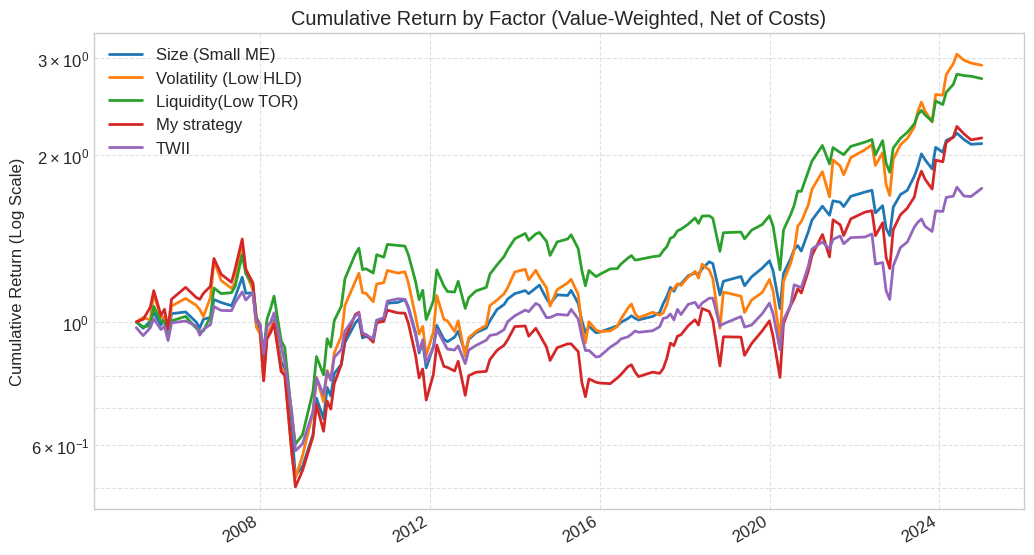

In [58]:
# === 5. Cumulative Return (Log-Scale Visualization) ===

# Find the common dates for all strategies and the benchmark
common_idx = res_size_vw.index.intersection(res_vol_vw.index)\
             .intersection(res_liq_vw.index).intersection(ret_twii.index)

# Create cumulative return dataframe
cum_df = pd.concat([
    (1 + res_size_vw.loc[common_idx, 'NetReturn']).cumprod().rename('Size (Small ME)'),
    (1 + res_vol_vw.loc[common_idx, 'NetReturn']).cumprod().rename('Volatility (Low HLD)'),
    (1 + res_liq_vw.loc[common_idx, 'NetReturn']).cumprod().rename('Liquidity(Low TOR)'),
    (1 + res_my_start.loc[common_idx, 'NetReturn']).cumprod().rename('My strategy'),
    (1 + ret_twii.loc[common_idx, '^TWII']).cumprod().rename('TWII')
], axis=1)

# Plot
ax = cum_df.plot(title="Cumulative Return by Factor (Value-Weighted, Net of Costs)", lw=2, figsize=(12, 7))
ax.set_ylabel("Cumulative Return (Log Scale)")
ax.set_yscale("log")
ax.grid(True, which='both', ls='--', alpha=0.6)
plt.legend()
plt.show()